<a href="https://colab.research.google.com/github/alottamyles/Hystrix/blob/2026fall_myles/coding_exercise_ML_basics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
# Data source: Kaggle - USA House Sales Data
# URL: https://www.kaggle.com/datasets/abdulwadood11220/usa-house-sales-data
# Read dataset
df = pd.read_csv('us_house_Sales_data.csv')
# Convert text values into numbers for Price, Area (Sqft), and Location
df["Price"] = df["Price"].str.replace("$", "").str.replace(",", "").astype(float)
df["Area (Sqft)"] = df["Area (Sqft)"].str.replace(" sqft", "").astype(float)
#Rename columns to match dataset
df = df.rename(columns={
    "Price": "price",
    "Area (Sqft)": "square_footage",
    "City": "location"
})
# Features and target
X = df[['square_footage', 'location']]
y = df['price']
# Preprocessing: One-hot encode the location column
preprocessor = ColumnTransformer(
transformers=[
('location', OneHotEncoder(sparse_output=False), ['location'])
], remainder='passthrough')
# Create pipeline with preprocessing and model
model = Pipeline(steps=[
('preprocessor', preprocessor),
('regressor', LinearRegression())
])
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
random_state=42)
# Train model
model.fit(X_train, y_train)
# Make prediction for a new house: 2000 sq ft in Los Angeles
new_house = pd.DataFrame({'square_footage': [2000], 'location': ['Los Angeles']})
predicted_price = model.predict(new_house)
print(f"Predicted price for a 2000 sq ft house in Los Angeles: ${predicted_price[0]:,.2f}")
# Display model coefficients

# Square_footage coefficient represents the estimated change in house price for each additional sqft
# Location coefficient represents the connection between city and price, taking square footage into account
# Positive (+) values = higher predicted prices
# Negative (-) values = lower predicted prices
feature_names = (
    model.named_steps['preprocessor']
    .named_transformers_['location']
    .get_feature_names_out(['location'])
    .tolist()
    + ['square_footage']
)
coefficients = model.named_steps['regressor'].coef_
print("\nModel Coefficients:")
for feature, coef in zip(feature_names, coefficients):
    print(f"{feature}: {coef:.2f}")

Predicted price for a 2000 sq ft house in Los Angeles: $827,269.28

Model Coefficients:
location_Fresno: 17640.38
location_Los Angeles: 7741.22
location_Sacramento: -7750.17
location_San Diego: -947.34
location_San Francisco: -16684.09
square_footage: -18.42


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
# Data source: Kaggle - Telcom Customer Churn Dataset
# URL: https://www.kaggle.com/datasets/mosapabdelghany/telcom-customer-churn-dataset

# Read dataset
df = pd.read_csv("Telco_Cusomer_Churn.csv")

# Rename columns
df = df.rename(columns={
    "SeniorCitizen": "senior_citizen",
    "MonthlyCharges": "monthly_charges",
    "InternetService": "internet_service",
    "Contract": "contract",
    "Churn": "churn"
})

# Features and target
X = df[['senior_citizen', 'tenure', 'monthly_charges', 'contract',
'internet_service']]
y = df['churn']
# Preprocessing: Scale numerical features and one-hot encode categorical features
preprocessor = ColumnTransformer(
transformers=[
('num', StandardScaler(), ['senior_citizen', 'tenure', 'monthly_charges']),
('cat', OneHotEncoder(sparse_output=False), ['contract', 'internet_service'])
])
# Create pipeline with preprocessing and model
model = Pipeline(steps=[
('preprocessor', preprocessor),
('classifier', LogisticRegression(random_state=42))
])
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
random_state=42)
# Train model
model.fit(X_train, y_train)
# Predict churn probability for a new customer
new_customer = pd.DataFrame({
'senior_citizen': [0],
'tenure': [12],
'monthly_charges': [70],
'contract': ["Month-to-month"],
'internet_service': ['Fiber optic']
})
churn_probability = model.predict_proba(new_customer)[0][1] # Probability of churn (class 1)
# Classify based on threshold (0.5)
threshold = 0.5
churn_prediction = 1 if churn_probability > threshold else 0
print(f"Churn Probability for new customer: {churn_probability:.2f}")
print(f"Churn Prediction (1 = churn, 0 = no churn): {churn_prediction}")

# Display model coefficients
feature_names = (['senior_citizen', 'tenure', 'monthly_charges'] +
                 model.named_steps['preprocessor']
                 .named_transformers_['cat']
                 .get_feature_names_out(['contract', 'internet_service'])
                 .tolist())
coefficients = model.named_steps['classifier'].coef_[0]
print("\nModel Coefficients:")
for feature, coef in zip(feature_names, coefficients):
    print(f"{feature}: {coef:.2f}")

Churn Probability for new customer: 0.58
Churn Prediction (1 = churn, 0 = no churn): 1

Model Coefficients:
senior_citizen: 0.12
tenure: -0.78
monthly_charges: 0.13
contract_Month-to-month: 0.45
contract_One year: -0.37
contract_Two year: -1.24
internet_service_DSL: -0.42
internet_service_Fiber optic: 0.53
internet_service_No: -1.27


This model predicts the probability that a new customer will churn. If probability > 0.5, the customer is classified as likely to churn. In this case, the probability is above 0.5, so the customer is considered highly probable to leave. A business could use this prediction model to target the customer with retention offers, discounts, or better customer support.

   customer_id  age  annual_income  months_active  avg_monthly_spend  \
0        33554   53  100473.211709             63         121.430565   
1         9428   54   54730.644845             67         572.552674   
2          200   44   58268.121079             57         266.593896   
3        12448   54   64829.795654             40         691.452358   
4        39490   28   27431.467873             15         832.664792   

   purchase_frequency  avg_order_value  discount_usage_rate  return_rate  \
0            0.817268        66.820403             0.117256     0.023144   
1            3.176551       137.087449             0.261647     0.429054   
2            2.713168        71.796888             0.284785     0.011854   
3            5.553977       105.501185             0.104832     0.399686   
4            1.348389       354.568534             0.409204     0.039517   

   browsing_time_minutes  support_interactions payment_method      region  \
0              77.298393         

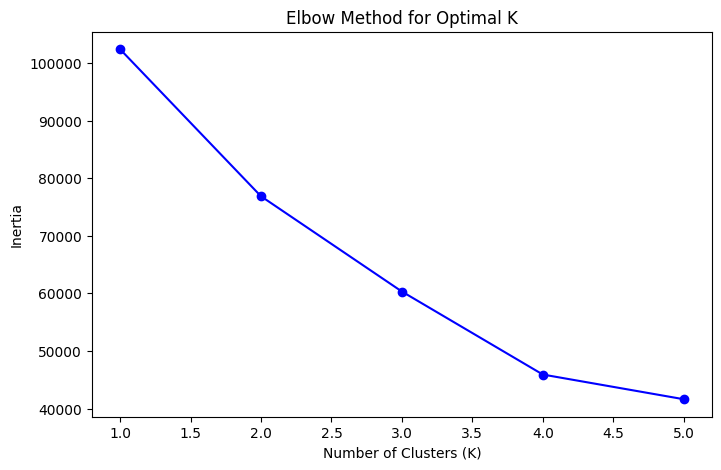

Cluster Characteristics:
         annual_spending  purchase_frequency    age
cluster                                            
0                3664.13               11.06  44.11
1                3227.12                3.80  58.26
2                8235.72                4.29  43.75
3                3219.13                3.79  30.37

Cluster 0 Strategy:
Frequent buyers: Offer loyalty rewards.

Cluster 1 Strategy:
Older customers: Offer targeted discounts.

Cluster 2 Strategy:
Low-engagement customers: Send personalized re-engagement campaigns.

Cluster 3 Strategy:
Younger customers: Send digital promotions.


In [32]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
# Generate sample customer data
# Data source: Online Retail Customer Segmentation Dataset
# URL: https://www.kaggle.com/datasets/rohit8527kmr7518/online-retail-customer-classification-dataset

# Read dataset
df = pd.read_csv('retail_customer_segmentation.csv')

df['annual_spending'] = df['avg_monthly_spend'] * 12

print(df.head())

# Drop rows with any NaN values before preprocessing
df.dropna(inplace=True)

# Preprocess data: Select numerical features and scale them
features = ['annual_spending', 'purchase_frequency', 'age']
X = df[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# Determine optimal number of clusters using elbow method
inertia = []
K = range(1, 6)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
# Plot elbow curve
plt.figure(figsize=(8, 5))
plt.plot(K, inertia, 'bo-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.savefig('elbow_plot.png')
plt.show()
plt.close()
# Apply K-Means with optimal K (e.g., 3 based on elbow method)
optimal_k = 4
# K=4 was selected because the elbow plot begins to flatten after 4 clusters
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init='auto')
df['cluster'] = kmeans.fit_predict(X_scaled)
# Analyze clusters
cluster_summary = df.groupby('cluster')[features].mean().round(2)
print("Cluster Characteristics:")
print(cluster_summary)
# Example of targeted strategies
for cluster in range(optimal_k):
    print(f"\nCluster {cluster} Strategy:")
    if cluster_summary.loc[cluster, 'purchase_frequency'] > 8:
        print("Frequent buyers: Offer loyalty rewards.")
    elif cluster_summary.loc[cluster, 'age'] > 50:
        print("Older customers: Offer targeted discounts.")
    elif cluster_summary.loc[cluster, 'age'] < 35:
        print("Younger customers: Send digital promotions.")
    else:
        print("Low-engagement customers: Send personalized re-engagement campaigns.")
# Save cluster assignments to CSV
df.to_csv('customer_segments.csv', index=False)